###  This notebook is used to optimize Hyperparameters of GradientBoostingRegressor() predicting DIN [%] box-cox redfield normalized concentrations:

In [1]:
# load required moduls:

# load required moduls:
# pandas is used for data manipulation:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn import metrics
from numpy import mean
from numpy import std
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
import os

In [2]:
import multiprocessing
multiprocessing.cpu_count()

22

In [3]:
# define the output folder path:

output_folder = '../../../output_data/ML_analysis/hyperparameter_settings'

# Check if the folder exists, if not, create it:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)



#### 1. import data:

In [5]:
nutrient_export_data = pd.read_csv('../../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [6]:
#nutrient_export_data.info()

## Prepare the data for the machine learning models:

1. Split data into features and targets
2. Convert data frame to arrays 
3. Split data into training and test set

1. Function to prepare input data: split data into target and features and convert to arrays: 

In [7]:

def create_input_ML(data, target_var):

    # create array with exported nutrient values, which are our target values, we want to predict 
    target = np.array(nutrient_export_data[target_var])


    # remove the labels from the features df:

    features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
    #features = nutrient_export_data.filter(items=selected_features)

    #select columns by index: 
    features= features.iloc[:,:]
    features.columns

    # save feature list for later use:
    feature_list = list(features.columns)

    # convert to numpy array:
    features = np.array(features)

    return target, features, feature_list

### Apply create_input_ML function: set data and target_var

In [8]:
# choose target var: "n_imbal", "p_imbal" or "c_imbal":
target_var = "n_imbal"

# data:
data = nutrient_export_data

In [9]:
target, features, feature_list = create_input_ML(data = data, target_var = target_var)

In [10]:
len(feature_list)

33

### Split data into training and testing set: 

### set test_size and random_state

In [11]:
# test size: usually 0.2 or 0.25:
test_size = 0.2
#set random_state:
random_state = 41 # before I used random_state=41


In [12]:

# using Skicit-learn to split data into training and testing sets:
from sklearn.model_selection import train_test_split

train_features, test_features, train_targets, test_targets = train_test_split(features, target, test_size = test_size, random_state = random_state) 



Check data structure: targets and features should have same length in training and test set:

In [13]:
print('Training Features Shape:', train_features.shape)
print('Training targets Shape:', train_targets.shape)
print('Testing Features Shape:', test_features.shape)
print('Testing targets Shape:', test_targets.shape)

Training Features Shape: (2796, 33)
Training targets Shape: (2796,)
Testing Features Shape: (700, 33)
Testing targets Shape: (700,)


### Box-Cox transformation of training and testing targets:

In [14]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')

# Reshape train_targets to 2D if it's 1D
if len(train_targets.shape) == 1:
    train_targets2 = np.reshape(train_targets, (-1, 1))

# Fit the transformer to the training data
# This learns the best lambda value for each feature
pt.fit(train_targets2)

# Transform the training data using the learned lambda values
train_targets_transformed_bc = pt.transform(train_targets2)
# convert back to 1D format
train_targets_transformed_bc = train_targets_transformed_bc.ravel()

# Transform the test data using the same lambda values
# Reshape test_targets to 2D if it's 1D
if len(test_targets.shape) == 1:
    test_targets2 = np.reshape(test_targets, (-1, 1))

test_targets_transformed_bc = pt.transform(test_targets2)
test_targets_transformed_bc = test_targets_transformed_bc.ravel()

### Plot data and transformed data testing and training set:

C:\Users\alexd\AppData\Local\Temp\ipykernel_32168\3265750013.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


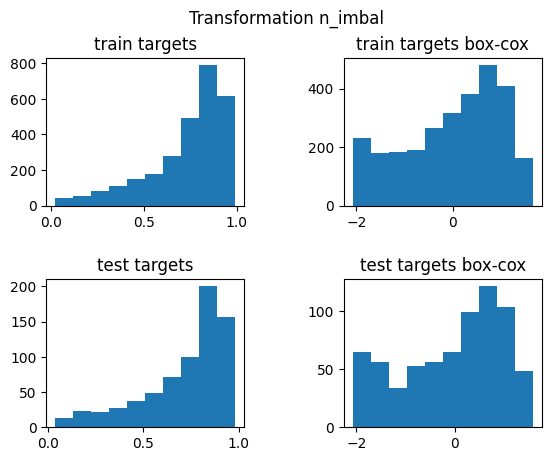

In [15]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2)
# Plot data on each subplot
axs[0, 0].hist(train_targets)
axs[0, 0].set_title('train targets')

axs[0, 1].hist(train_targets_transformed_bc)
axs[0, 1].set_title('train targets box-cox')

axs[1, 0].hist(test_targets)
axs[1, 0].set_title('test targets')

axs[1, 1].hist(test_targets_transformed_bc)
axs[1, 1].set_title('test targets box-cox')
fig.subplots_adjust(hspace=0.5, wspace=0.5)
fig.suptitle(f'Transformation {target_var}')
fig.show()

### Import model functions from sklearn:

In [16]:
# import models
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics


# Fit Boosting regression tree and random forest model: first with default parameters:

In [17]:
def_parms_brt = {
    "n_estimators": 7000,
    "max_depth": 9,
    "min_samples_split": 5,
    "learning_rate": 0.001, # before i had 0.005
    "loss": "squared_error",
    "subsample": 0.5,
}


def_parms_rf = {
    "n_estimators": 6000,
    "max_depth": 4,
}

model = "brt"

cross_val = RepeatedKFold(n_splits=2, n_repeats=2, random_state=1)


### fit Gradient Boosting Regressor with default parameters: 

In [17]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from datetime import datetime
import os

def run_model_def_parms(model, parms, target_var, train_features, test_features, train_targets, test_targets, cross_val):
    
    if target_var == "n_imbal":
        comp = "DIN"
    if target_var == "p_imbal":
        comp = "SRP"
    if target_var == "c_imbal":
        comp = "OC"
    
    
    if model == "brt":
        ml_model = GradientBoostingRegressor(**parms,  random_state = 5)
    if model == "rf":
        ml_model = RandomForestRegressor(**parms)

    
    #n_scores = cross_val_score(ml_model, train_features, train_targets, scoring='r2', cv=cross_val, n_jobs=4, error_score='raise')
    #print('Cross validation R2: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))


    # Train the model on all training data: 
    ml_model.fit(train_features, train_targets);

    # evaluate model with test data:
    predictions = ml_model.predict(test_features)

    # pred on training data: 
    pred_train = ml_model.predict(train_features)

    if model == "brt":
        test_score = np.zeros((parms["n_estimators"],), dtype=np.float64)
        for i, y_pred in enumerate(ml_model.staged_predict(test_features)):
            test_score[i] = mean_squared_error(test_targets, y_pred)

        fig = plt.figure(figsize=(6, 6))
        plt.subplot(1, 1, 1)
        plt.title("Deviance")
        plt.plot(
            np.arange(parms["n_estimators"]) + 1,
            ml_model.train_score_,
            "b-",
            label="Training Set Deviance",
            )
        plt.plot(
            np.arange(parms["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
            )
        plt.legend(loc="upper right")
        plt.xlabel("Boosting Iterations")
        plt.ylabel("Deviance")
        fig.tight_layout()
        plt.show()

    
    # plot predictions on training data and testing data:

    # first training data:
    
    plt.scatter(train_targets, pred_train) 
    plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
    plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
    plt.title(f" Training data model: {str(model)} predicting {target_var}", fontsize=14)
    r2 = r2_score(train_targets, pred_train)
    # add line of linear model
    
    plt.plot(test_targets, test_targets, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
    plt.legend()
    plt.show()
            

    
    
    #now testing data:
    plt.scatter(test_targets, predictions) 
    plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
    plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
    plt.title(f" Testing data model: {str(model)} predicting {target_var}", fontsize=14)
    r2 = r2_score(test_targets, predictions)
    # add line of linear model
    
    plt.plot(test_targets, test_targets, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
    plt.legend()
    plt.show()

    r2_test = r2_score(test_targets, predictions)
    r2_test
    
    MAPE = mean_absolute_percentage_error(test_targets, predictions)
    print(f"Model: {str(model)} --> MAPE = {MAPE*100.0:.2f}")
    
    mse = mean_squared_error(test_targets, ml_model.predict(test_features))
    print("The mean squared error (MSE) on test set: {:.4f}".format(mse))
    
    mae = mean_absolute_error(test_targets, ml_model.predict(test_features))
    print("The mean absolute error (MAE) on test set: {:.4f}".format(mae))

    # return fitted model:
    return ml_model



    

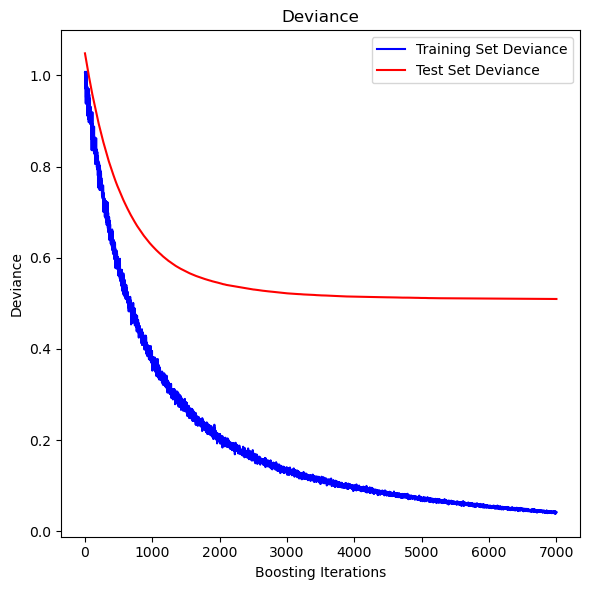

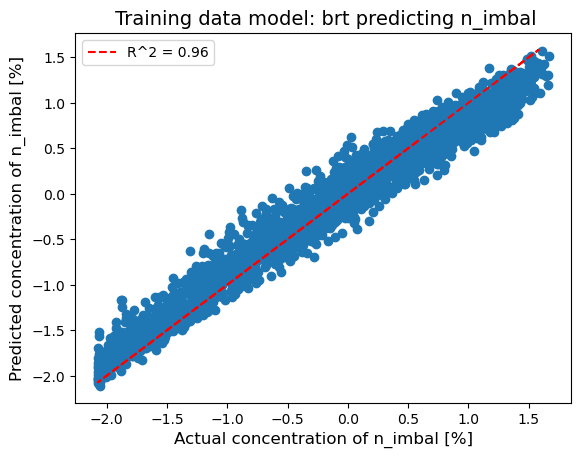

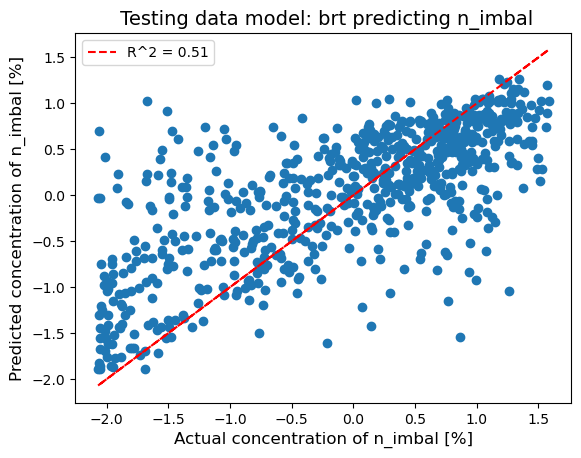

Model: brt --> MAPE = 305.09
The mean squared error (MSE) on test set: 0.5096
The mean absolute error (MAE) on test set: 0.5267


In [58]:
model_fitted = run_model_def_parms(model = model, target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc, cross_val = cross_val, parms = def_parms_brt)

In [255]:
### Define a function to write infos of fitted model to csv file:

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append('../')
from functions_ml_analysis import info_fitted_model_to_csv  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
info_fitted_model_to_csv(fitted_model = model_fitted, target_var = 'n_imbal', train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: base parameters 


True


### Fit the model with same parameters as above but use early stopping if loss is not improving by adding more trees:

In [62]:
gbm_early_stopping = GradientBoostingRegressor(
    **def_parms_brt,
    random_state = 5,
    validation_fraction=0.1,
    n_iter_no_change= int(def_parms_brt['n_estimators']* 0.1), #use 10 percent of n_estimators
)

gbm_early_stopping.fit(train_features, train_targets_transformed_bc)

preds_test = gbm_early_stopping.predict(test_features)
print(f"R2_score{r2_score(test_targets_transformed_bc, preds_test):2f}")
print(f"MAPE = {mean_absolute_percentage_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MSE = {mean_squared_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MAE ={mean_absolute_error(test_targets_transformed_bc, preds_test):2f}")

R2_score0.507477
MAPE = 2.693096
MSE = 0.515441
MAE =0.532033


In [63]:
gbm_early_stopping.n_estimators_

4935

In [64]:
info_fitted_model_to_csv(fitted_model = gbm_early_stopping, target_var = 'n_imbal', train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: test early stopping , stopped after 4935 iterations


True


In [19]:
#run_model_def_parms(model = "rf", target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets, test_targets = test_targets, cross_val = cross_val, parms = def_parms_rf)

### Apply parameter tuning using RandomizedSearchCV():

In [39]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform

# Define the model: 
model = GradientBoostingRegressor(random_state = 5) 


# define the evaluation procedure
from sklearn.model_selection import RepeatedKFold
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)


# define scoring functions:

scoring = {"R2": "r2", "MAE": "neg_mean_absolute_error"}


# set parameter ranges
params_random = {'max_depth':  np.arange(5, 14), 
         #'min_samples_leaf': np.arange(2, 11),
          'max_features': np.arange(2, 33),
         "subsample": np.arange(0.5,1, 0.1),
         "learning_rate":  loguniform(a=1e-3, b=1e0), #np.linspace(start = 0.001, stop = 0.4, num = 1200),
         "n_estimators":np.arange(1000, 8000, 50)}

gridrandom = RandomizedSearchCV(estimator = model,
                                param_distributions = params_random,
                                cv= cv, 
                                verbose= 10, 
                                n_jobs= 60,
                                refit = "R2",
                                scoring = scoring,
                                return_train_score=True,
                                n_iter = 2500,
                                )
                                

# summarize the best score and configuration
#print("Best: %f using %s" % (gridsearch_result.best_score_, gridsearch_result.best_params_)) # summarize all scores that were evaluated
#means = gridsearch_result.cv_results_['mean_test_score']
#stds = grid_result.cv_results_['std_test_score']
#params = grid_result.cv_results_['params']
#for mean, stdev, param in zip(means, stds, params):
 #   print("%f (%f) with: %r" % (mean, stdev, param))

In [40]:
params_random

{'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13]),
 'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
 'subsample': array([0.5, 0.6, 0.7, 0.8, 0.9]),
 'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x1e71596af10>,
 'n_estimators': array([1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500,
        1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000, 2050,
        2100, 2150, 2200, 2250, 2300, 2350, 2400, 2450, 2500, 2550, 2600,
        2650, 2700, 2750, 2800, 2850, 2900, 2950, 3000, 3050, 3100, 3150,
        3200, 3250, 3300, 3350, 3400, 3450, 3500, 3550, 3600, 3650, 3700,
        3750, 3800, 3850, 3900, 3950, 4000, 4050, 4100, 4150, 4200, 4250,
        4300, 4350, 4400, 4450, 4500, 4550, 4600, 4650, 4700, 4750, 4800,
        4850, 4900, 4950, 5000, 5050, 5100, 5150, 5200, 5250, 5300, 5350,
        5400, 5450, 5500, 5550, 56

In [42]:
%%time
# search_result = 
gridrandom.fit(train_features, train_targets_transformed_bc)

Fitting 30 folds for each of 2500 candidates, totalling 75000 fits
CPU times: total: 6min 21s
Wall time: 1d 19h 20min 54s


RandomizedSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
                   estimator=GradientBoostingRegressor(random_state=5),
                   n_iter=2500, n_jobs=60,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E71596AF10>,
                                        'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13]),
                                        'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9...
       5400, 5450, 5500, 5550, 5600, 5650, 5700, 5750, 5800, 5850, 5900,
       5950, 6000, 6050, 6100, 6150, 6200, 6250, 6300, 6350, 6400, 6450,
       6500, 6550, 6600, 6650, 6700, 6750, 6800, 6850, 6900, 6950, 7000,
       7050, 7100, 7150, 7200, 7250, 7300, 7350, 7400, 7450, 7500, 7550,
       7600, 7650, 7700, 7750, 7800, 7850, 7900, 7950]),
                                        'subsample': array([0.5, 0.6, 0.7, 0.8, 0.9])},
                   refit='R2', return_train_score=True,
                   scoring={'MAE': 'neg_mean_absolute_error', 'R2': 'r2'},
                   verbose=10)

In [43]:
print(gridrandom.best_params_)
print(gridrandom.best_score_)

{'learning_rate': 0.001524207186070734, 'max_depth': 11, 'max_features': 7, 'n_estimators': 7300, 'subsample': 0.5}
0.5413432582666287


In [44]:
gridrandom.get_params

<bound method BaseEstimator.get_params of RandomizedSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
                   estimator=GradientBoostingRegressor(random_state=5),
                   n_iter=2500, n_jobs=60,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E71596AF10>,
                                        'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13]),
                                        'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9...
       5400, 5450, 5500, 5550, 5600, 5650, 5700, 5750, 5800, 5850, 5900,
       5950, 6000, 6050, 6100, 6150, 6200, 6250, 6300, 6350, 6400, 6450,
       6500, 6550, 6600, 6650, 6700, 6750, 6800, 6850, 6900, 6950, 7000,
       7050, 7100, 7150, 7200, 7250, 7300, 7350, 7400, 7450, 7500, 7550,
       7600, 7650, 7700, 7750, 7800, 7850, 7900, 7950]),
                                        'subsample': array([0.5, 0.6, 0.7, 0

In [45]:
# apply optimized model:

preds_test = gridrandom.predict(test_features)

preds_train = gridrandom.predict(train_features)

In [46]:
from sklearn.metrics import r2_score
r2_score(train_targets_transformed_bc, preds_train)

0.9965453382679605

In [47]:

print(f"R2_score{r2_score(test_targets_transformed_bc, preds_test):2f}")
print(f"MAPE = {mean_absolute_percentage_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MSE = {mean_squared_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MAE ={mean_absolute_error(test_targets_transformed_bc, preds_test):2f}")

R2_score0.513893
MAPE = 2.957007
MSE = 0.508727
MAE =0.522928


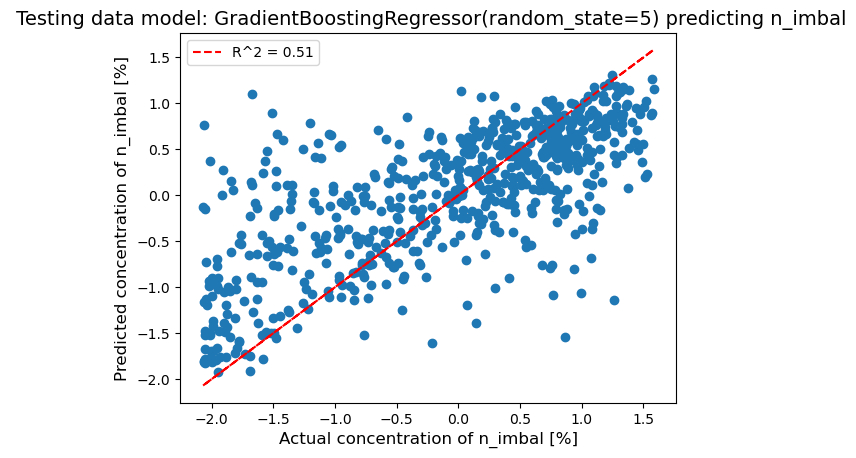

In [48]:
plt.scatter(test_targets_transformed_bc, preds_test) 
plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
plt.title(f" Testing data model: {str(model)} predicting {target_var}", fontsize=14)
r2 = r2_score(test_targets_transformed_bc, preds_test)
 # add line of linear model
    
plt.plot(test_targets_transformed_bc, test_targets_transformed_bc, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
plt.legend()
plt.show()

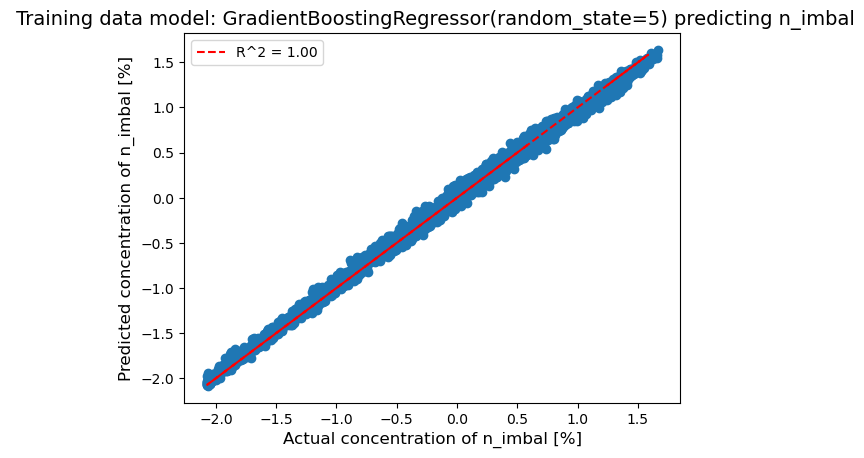

In [49]:
plt.scatter(train_targets_transformed_bc, preds_train) 
plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
plt.title(f" Training data model: {str(model)} predicting {target_var}", fontsize=14)
r2 = r2_score(train_targets_transformed_bc, preds_train)
# add line of linear model
    
plt.plot(test_targets_transformed_bc, test_targets_transformed_bc, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
plt.legend()
plt.show()
            

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
#sys.path.append('Y:/Home/bartusch/cnp-synthesis/python/ML_analysis/')
sys.path.append('../../../')
from functions_ml_analysis import info_fitted_model_to_csv  

In [51]:
info_fitted_model_to_csv(fitted_model = gridrandom, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: RandomizedSearchCV() optimization n_imbal  1d 19h 20min 54s


True


### Now calculate importances of factors:

In [331]:
# create array with exported nutrient values, which are our target values, we want to predict 
#target = np.array(nutrient_export_data['c_imbal'])
target = nutrient_export_data[target_var]

# remove the labels from the features df:

features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
#features = nutrient_export_data.filter(items=selected_features)

#select columns by index: 
features= features.iloc[:,0:43]
features.columns

# save feature list for later use:
feature_list = list(features.columns)


In [18]:
params = {'learning_rate': 0.001524207186070734, 'max_depth': 11, 'max_features': 7, 'n_estimators': 7300, 'subsample': 0.5}
brt = GradientBoostingRegressor(**params)
brt.fit(train_features, train_targets_transformed_bc)

GradientBoostingRegressor(learning_rate=0.001524207186070734, max_depth=11,
                          max_features=7, n_estimators=7300, subsample=0.5)

In [19]:
pred_test_test = brt.predict(test_features)
r2_score(test_targets_transformed_bc, pred_test_test)

0.5151638663329465

### Compare to a model with early stopping: 

In [24]:
params = {'learning_rate': 0.001524207186070734, 'max_depth': 11, 'max_features': 7, 'n_estimators': 7300, 'subsample': 0.5}
brt_early_stop = GradientBoostingRegressor(**params, validation_fraction = 0.1, n_iter_no_change = 10)
brt_early_stop.fit(train_features, train_targets_transformed_bc)

GradientBoostingRegressor(learning_rate=0.001524207186070734, max_depth=11,
                          max_features=7, n_estimators=7300,
                          n_iter_no_change=10, subsample=0.5)

In [25]:
pred_test_earlys = brt_early_stop.predict(test_features)
r2_score(test_targets_transformed_bc, pred_test_earlys)

0.5002116167931234

In [26]:
pred_train_earlys = brt_early_stop.predict(train_features)
r2_score(train_targets_transformed_bc, pred_train_earlys)

0.8652421686557178

In [67]:
params_optimum = {'learning_rate': 0.001524207186070734, 'max_depth': 11, 'max_features': 7, 'n_estimators': 7300, 'subsample': 0.5}
 
brt_model = GradientBoostingRegressor()

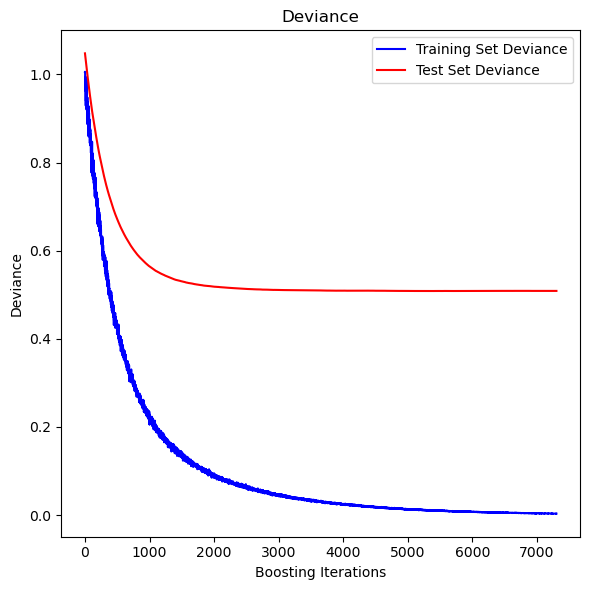

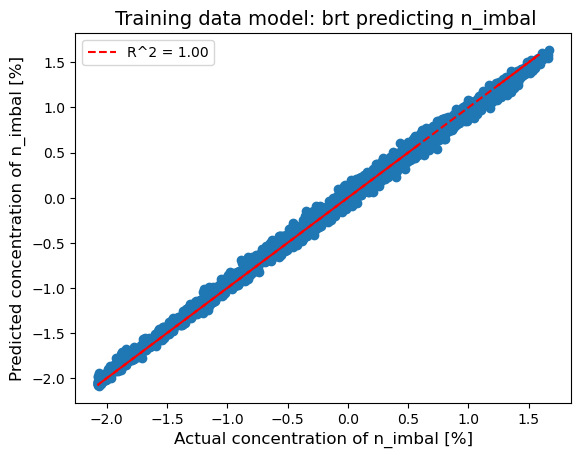

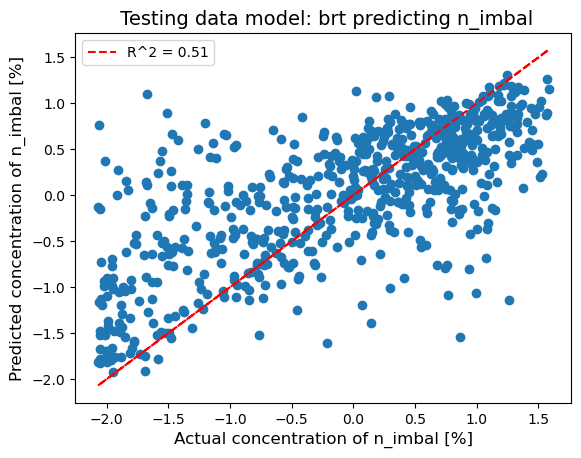

Model: brt --> MAPE = 295.70
The mean squared error (MSE) on test set: 0.5087
The mean absolute error (MAE) on test set: 0.5229


GradientBoostingRegressor(learning_rate=0.001524207186070734, max_depth=11,
                          max_features=7, n_estimators=7300, random_state=5,
                          subsample=0.5)

In [68]:
run_model_def_parms(model = "brt", target_var = 'n_imbal', train_features = train_features, test_features = test_features , train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc, cross_val = cross_val, parms = params_optimum)

In [69]:
test_features

array([[2.63340000e+03, 8.25013998e+00, 5.10000000e+01, ...,
        3.99000000e+02, 2.71168400e+10, 9.24000000e+02],
       [1.88900000e+02, 7.79439781e+00, 4.00000000e+01, ...,
        2.04000000e+02, 1.30287400e+09, 9.15000000e+02],
       [1.23000000e+02, 7.62879682e+00, 5.30000000e+01, ...,
        4.39000000e+02, 6.98039300e+09, 9.48000000e+02],
       ...,
       [6.61500000e+02, 1.16121094e+01, 5.50000000e+01, ...,
        3.34000000e+02, 4.56864770e+09, 9.41000000e+02],
       [3.66100000e+02, 9.15791287e+00, 1.40000000e+01, ...,
        5.19100000e+03, 3.97733440e+07, 9.39000000e+02],
       [8.69900000e+02, 7.19966437e+00, 7.70000000e+01, ...,
        3.81000000e+02, 3.52072550e+09, 9.18000000e+02]])

In [20]:
from sklearn.inspection import permutation_importance

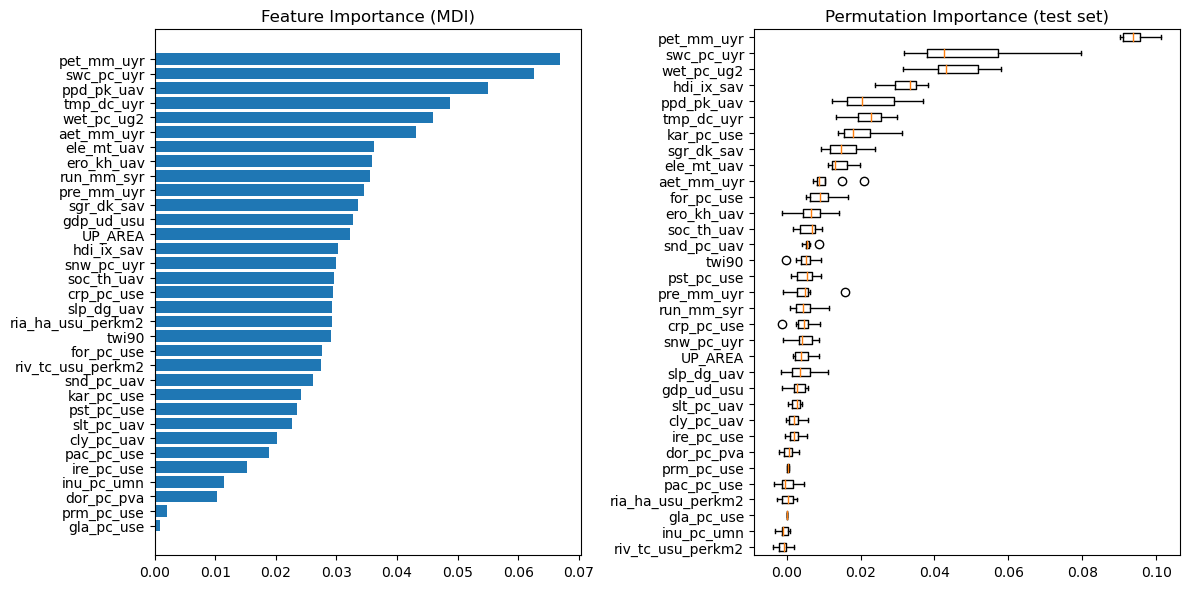

In [22]:
feature_importance = brt.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(feature_list)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    brt, test_features, test_targets_transformed_bc, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(feature_list)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.savefig('permutation_importances_n_imbalance_redfield')
plt.show()

Early stopping: brt_early_stop

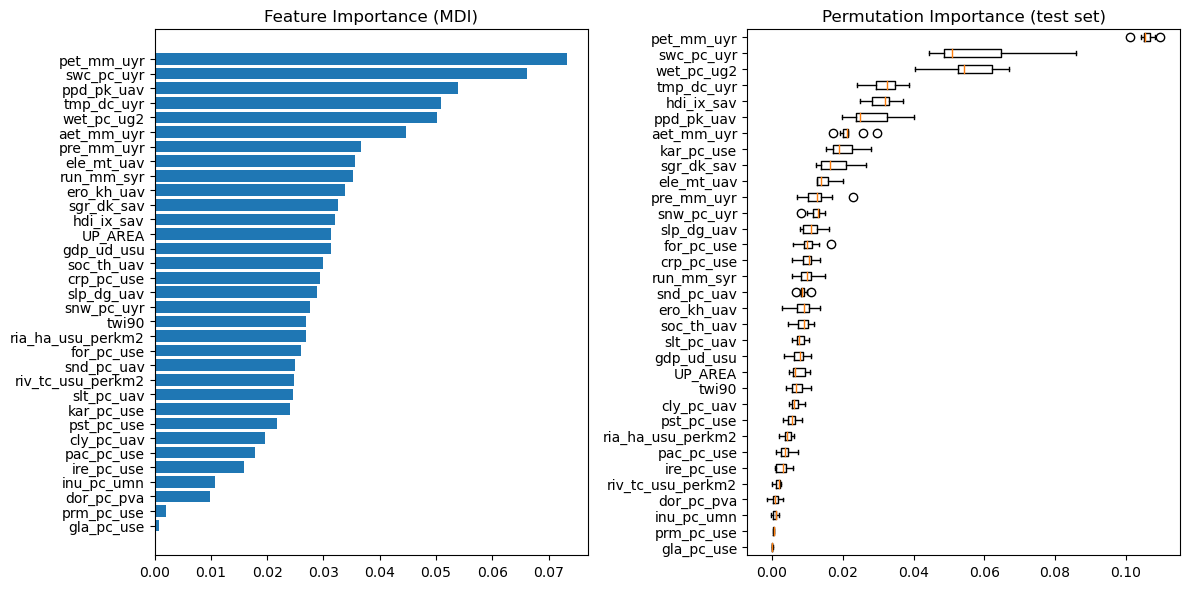

In [40]:
feature_importance = brt_early_stop.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(feature_list)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    brt_early_stop, test_features, test_targets_transformed_bc, n_repeats=10, random_state=42, n_jobs=2,
    scoring = 'r2'
    
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(feature_list)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

In [33]:
result2 = result.copy()

In [38]:
result2

{'importances_mean': array([0.00736226, 0.00712064, 0.01121953, 0.01032675, 0.01011438,
        0.00570234, 0.02793372, 0.00993256, 0.00087817, 0.00101471,
        0.00431977, 0.00167278, 0.01485847, 0.017702  , 0.03188128,
        0.01286652, 0.10570201, 0.02174956, 0.01235647, 0.05577837,
        0.00291499, 0.00013935, 0.00045221, 0.00386434, 0.00669696,
        0.00786293, 0.00872708, 0.00859033, 0.05733579, 0.02031804,
        0.00859744, 0.00755892, 0.03091471]),
 'importances_std': array([1.99288357e-03, 2.19667677e-03, 2.54311335e-03, 2.83881258e-03,
        2.09230029e-03, 1.57599895e-03, 6.68149658e-03, 2.53733381e-03,
        7.23477067e-04, 1.26097419e-03, 1.33654235e-03, 8.85831494e-04,
        2.61979452e-03, 4.42838209e-03, 4.22390062e-03, 4.29142542e-03,
        2.19327066e-03, 3.36731970e-03, 1.94578342e-03, 7.61755595e-03,
        1.69257842e-03, 2.72614442e-05, 1.89722882e-04, 1.72532938e-03,
        1.37706756e-03, 1.41180136e-03, 1.07435472e-03, 2.06286189e-03,
   

In [39]:
print("Mean importances:", result.importances_mean)
print("Standard deviations:", result.importances_std)

Mean importances: [0.00736226 0.00712064 0.01121953 0.01032675 0.01011438 0.00570234
 0.02793372 0.00993256 0.00087817 0.00101471 0.00431977 0.00167278
 0.01485847 0.017702   0.03188128 0.01286652 0.10570201 0.02174956
 0.01235647 0.05577837 0.00291499 0.00013935 0.00045221 0.00386434
 0.00669696 0.00786293 0.00872708 0.00859033 0.05733579 0.02031804
 0.00859744 0.00755892 0.03091471]
Standard deviations: [1.99288357e-03 2.19667677e-03 2.54311335e-03 2.83881258e-03
 2.09230029e-03 1.57599895e-03 6.68149658e-03 2.53733381e-03
 7.23477067e-04 1.26097419e-03 1.33654235e-03 8.85831494e-04
 2.61979452e-03 4.42838209e-03 4.22390062e-03 4.29142542e-03
 2.19327066e-03 3.36731970e-03 1.94578342e-03 7.61755595e-03
 1.69257842e-03 2.72614442e-05 1.89722882e-04 1.72532938e-03
 1.37706756e-03 1.41180136e-03 1.07435472e-03 2.06286189e-03
 1.26485182e-02 4.06705291e-03 3.10077237e-03 2.04269760e-03
 3.47903795e-03]


In [41]:
print("Mean importances:", result.importances_mean)
print("Standard deviations:", result.importances_std)

Mean importances: [0.00736226 0.00712064 0.01121953 0.01032675 0.01011438 0.00570234
 0.02793372 0.00993256 0.00087817 0.00101471 0.00431977 0.00167278
 0.01485847 0.017702   0.03188128 0.01286652 0.10570201 0.02174956
 0.01235647 0.05577837 0.00291499 0.00013935 0.00045221 0.00386434
 0.00669696 0.00786293 0.00872708 0.00859033 0.05733579 0.02031804
 0.00859744 0.00755892 0.03091471]
Standard deviations: [1.99288357e-03 2.19667677e-03 2.54311335e-03 2.83881258e-03
 2.09230029e-03 1.57599895e-03 6.68149658e-03 2.53733381e-03
 7.23477067e-04 1.26097419e-03 1.33654235e-03 8.85831494e-04
 2.61979452e-03 4.42838209e-03 4.22390062e-03 4.29142542e-03
 2.19327066e-03 3.36731970e-03 1.94578342e-03 7.61755595e-03
 1.69257842e-03 2.72614442e-05 1.89722882e-04 1.72532938e-03
 1.37706756e-03 1.41180136e-03 1.07435472e-03 2.06286189e-03
 1.26485182e-02 4.06705291e-03 3.10077237e-03 2.04269760e-03
 3.47903795e-03]
